In [1]:
"""
MNIST 2‑D Latent‑Space VAE + Regressor Demo (precise latent region)
==================================================================
This script:
 1. Trains a 2‑dimensional **variational auto‑encoder** on MNIST.
 2. Encodes each digit to a latent vector and trains a **3‑layer MLP
    regressor** that maps latent → digit value.
 3. Draws **contours** of the regressor output across latent space.
 4. Overlays a **data‑driven latent region**: the highest‑density area of
    the latent distribution obtained via a 2‑D Gaussian‑kernel density
    estimate (KDE).  Compared with a convex hull, this KDE approach yields a
    far less regular, more faithful outline of where the data actually live.

Run with::
    python mnist_vae_latent_regression.py

Dependencies: torch, torchvision, matplotlib, scipy, scikit‑learn, numpy.
The script saves two figures:
    latent_contours.png   (contours + scatter)
    latent_region.png     (contours + irregular filled region)
"""
from __future__ import annotations
import math
import pathlib
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from matplotlib import cm
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

DATA_DIR = pathlib.Path("./data")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 2
BATCH_SIZE = 128
VAE_EPOCHS = 10
REG_EPOCHS = 30
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# -----------------------------------------------------------------------------
# DATA
# -----------------------------------------------------------------------------

def load_mnist():
    tf = torchvision.transforms.ToTensor()
    train_ds = torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=tf)
    test_ds = torchvision.datasets.MNIST(DATA_DIR, train=False, download=True, transform=tf)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, test_loader, train_ds.targets.float(), test_ds.targets.float()

# -----------------------------------------------------------------------------
# VAE ARCHITECTURE
# -----------------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
        )
        self.mu = nn.Linear(400, LATENT_DIM)
        self.logvar = nn.Linear(400, LATENT_DIM)

    def forward(self, x):  # -> (mu, logσ²)
        h = self.net(x)
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc, self.dec = Encoder(), Decoder()

    @staticmethod
    def reparameterize(mu, logvar):
        std, eps = torch.exp(0.5 * logvar), torch.randn_like(logvar)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparameterize(mu, logvar)
        return self.dec(z), mu, logvar

def vae_loss(x_hat, x, mu, logvar):
    recon = nn.functional.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

# -----------------------------------------------------------------------------
# REGRESSOR
# -----------------------------------------------------------------------------
class MLPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------------------------------------------------------
# TRAINING HELPERS
# -----------------------------------------------------------------------------

def train_vae(model, loader):
    opt = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(1, VAE_EPOCHS + 1):
        total = 0.0
        for x, _ in loader:
            x = x.to(DEVICE)
            opt.zero_grad()
            x_hat, mu, logvar = model(x)
            loss = vae_loss(x_hat, x, mu, logvar)
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"VAE {epoch}/{VAE_EPOCHS} – loss: {total / len(loader.dataset):.2f}")


def encode_dataset(model, loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            mu, _ = model.enc(x)
            zs.append(mu.cpu())
            ys.append(y)
    return torch.cat(zs), torch.cat(ys).float()


def train_regressor(z_train, y_train):
    scaler = StandardScaler()
    z_train_scaled = scaler.fit_transform(z_train)
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(z_train_scaled).float(), y_train.view(-1, 1))
    loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)
    model = MLPRegressor().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    for epoch in range(1, REG_EPOCHS + 1):
        total = 0.0
        for z, y in loader:
            z, y = z.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred = model(z)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()
            total += loss.item() * len(z)
        if epoch % 10 == 0 or epoch == REG_EPOCHS:
            print(f"Regressor {epoch}/{REG_EPOCHS} – MSE: {total / len(loader.dataset):.2f}")
    model.cpu()
    return model, scaler

# -----------------------------------------------------------------------------
# VISUALISATION
# -----------------------------------------------------------------------------

DENSITY_QUANTILE = 0.50  # drop 5% lowest‑density points

def make_grid(z, buffer=1.0, n=300):
    z_np = z.numpy()
    xmin, ymin = z_np.min(0) - buffer
    xmax, ymax = z_np.max(0) + buffer
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, n), np.linspace(ymin, ymax, n))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    return xx, yy, grid


def plot_contours(model, scaler, z, y, filename="latent_contours.pdf"):
    xx, yy, grid = make_grid(z)
    grid_scaled = scaler.transform(grid)
    with torch.no_grad():
        zz = model(torch.from_numpy(grid_scaled)).view(len(yy), len(xx)).numpy()

    #select 1000 samples from z
    # idx = np.random.choice(len(z), 1000, replace=False)
    # z = z[idx]
    # y = y[idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    cntr = ax.contour(xx, yy, zz, levels=20, cmap=cm.viridis, linewidths=0.5)
    scat = ax.scatter(z[:, 0], z[:, 1], c=y, cmap=cm.viridis, s=4, alpha=1, label="Training Samples")
    # ax.legend(loc="top right")
    cntr = ax.contourf(xx, yy, zz, levels=np.linspace(0, 9, 20), cmap=cm.viridis, alpha=0.7)
    fig.colorbar(cntr, ax=ax, label="Regressed value", boundaries=np.linspace(0, 9, 10), ticks=np.arange(0, 10))
    ax.set_xlabel("Latent Dimension 1")
    ax.set_ylabel("Latent Dimension 2")
    # ax.set_title("Regressor contours in latent space (colored by true digit)")
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    print(f"Saved {filename}")
    return fig, ax


def plot_latent_region_precise(z, fig, ax, filename="latent_region.pdf"):
    """Fill an irregular region representing the *bulk* of latent density.

    We estimate a smooth density with Gaussian KDE, evaluate it over a grid,
    and keep cells whose density is above the (1 – quantile) threshold.  The
    result is a concave, data‑driven outline rather than a convex hull.
    """
    xx, yy, grid = make_grid(z, buffer=0.5, n=400)
    print(f"xx range: {xx.min()} to {xx.max()}")
    print(f"yy range: {yy.min()} to {yy.max()}")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    kde = gaussian_kde(z.T)
    density = kde(grid.T).reshape(xx.shape)
    thresh = np.quantile(density, DENSITY_QUANTILE)
    mask = density >= thresh

    # plot one filled contour representing the retained high‑density mask
    # ax.contourf(xx, yy, mask, levels=[0.5, 1], colors=["white"], alpha=0) # Commented out to avoid filling in white
    ax.contour(xx, yy, mask, levels=[0.5], colors="black", linewidths=1.0, linestyles="solid")

    # Mask the other area as 'Infeasible Decoding'
    mask_infeasible = density < thresh  # Invert the mask
    ax.contourf(xx, yy, mask_infeasible, levels=[0.5, 1], colors=['black'], alpha=1.0)  # Fill with black
    legend_elements = [Patch(facecolor='black', label='Leads to invalid decodings')]
    ax.legend(handles=legend_elements, loc="lower left")
    fig.savefig(filename, dpi=150)
    print(f"Saved {filename}")




In [2]:
DENSITY_QUANTILE = 0.5
start = time.time()
train_loader, _, _, _ = load_mnist()
# 1. VAE
vae = VAE().to(DEVICE)
train_vae(vae, train_loader)
# 2. Encode train set
z_train, y_train = encode_dataset(vae, train_loader)
# 3. Regressor
reg, scaler = train_regressor(z_train, y_train)

print(f"Finished in {time.time() - start:.1f}s.")

VAE 1/10 – loss: 191.36
VAE 2/10 – loss: 168.45
VAE 3/10 – loss: 163.79
VAE 4/10 – loss: 161.16
VAE 5/10 – loss: 159.36
VAE 6/10 – loss: 158.00
VAE 7/10 – loss: 156.91
VAE 8/10 – loss: 156.02
VAE 9/10 – loss: 155.21
VAE 10/10 – loss: 154.50
Regressor 10/30 – MSE: 3.56
Regressor 20/30 – MSE: 3.13
Regressor 30/30 – MSE: 3.02
Finished in 34.9s.


Saved latent_contours.pdf
xx range: -5.10444450378418 to 4.376649856567383
yy range: -5.308938026428223 to 4.541328430175781
Saved latent_region.pdf


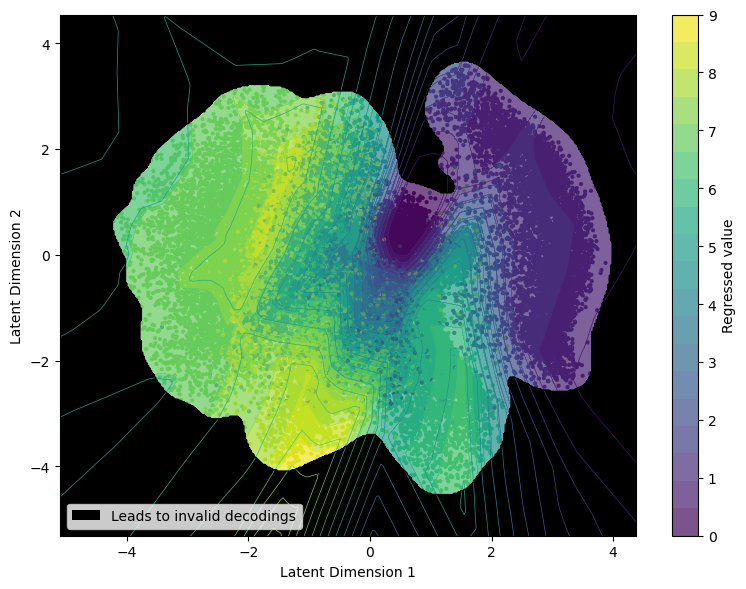

In [3]:
# 4. Visuals
fig, ax = plot_contours(reg, scaler, z_train, y_train)
plot_latent_region_precise(z_train, fig, ax)
# if "DISPLAY" in os.environ:
plt.show()